# New-panel climate-GEA — SNP vs non-SNP (raw LFMM + WZA), clq0.9 haploblocks

Raw **LFMM ridge K=16** (`calibrate='gif'`), env=bio1, on kMate gen9 pool Δp. **SNP** (1.99M records) vs **non-SNP = indel+SV pooled** (693k). Blocks = **clq0.9 haploblocks** (~82k genome-wide, median 188 bp), NOT the phase-1 LD blocks. Two views of each scan: the **raw per-record** LFMM, and the **WZA** (deg7-cap2000) block aggregation on the clq0.9 units.

In [1]:
import sys, os
PROJ='/global/scratch/users/tbellg/kmate'
sys.path.insert(0, f'{PROJ}/analysis/grenenet_gea')            # lib.py
sys.path.insert(0, f'{PROJ}/analysis/grenenet_gea/gea_newpanel')  # blocks_clq09
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl
import scipy.stats as st, lib
mpl.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
GNP=f'{PROJ}/results/grenenet_gea/gea_newpanel'
OUT=f'{GNP}/snp_vs_nonsnp'; os.makedirs(OUT, exist_ok=True)
CHR=[f'Chr{i}' for i in range(1,6)]
ACC={'snp':'#c1443c','nonsnp':'#2e7d5b'}; NAME={'snp':'SNP','nonsnp':'non-SNP (indel+SV)'}

## Load per-record (raw LFMM) + per-block (WZA), build genome coords

In [2]:
rec, wza = {}, {}
for cls in ['snp','nonsnp']:
    d=pd.read_csv(f'{GNP}/lfmm_{cls}_gen9_bio1_clq09.csv')
    d=d[np.isfinite(d.pval)].copy(); d['nlp']=-np.log10(d.pval.clip(1e-300))
    rec[cls]=d
    w=pd.read_csv(f'{GNP}/wza_{cls}_clq09.csv').rename(columns={'gene':'block','index':'block'})
    w=w[np.isfinite(w.Z_pVal)].copy(); w['pval']=w.Z_pVal; w['nlp']=-np.log10(w.Z_pVal.clip(1e-300))
    wza[cls]=w
# genome offsets from max pos per chrom across everything
chrlen={c:int(max(rec['snp'].loc[rec['snp'].chrom==c,'pos'].max(),
                  rec['nonsnp'].loc[rec['nonsnp'].chrom==c,'pos'].max())) for c in CHR}
off={}; run=0
for c in CHR: off[c]=run; run+=chrlen[c]+int(2e6)
ticks=[off[c]+chrlen[c]/2 for c in CHR]
for D in list(rec.values())+list(wza.values()):
    D['gx']=D.pos.astype(float)+D.chrom.map(off)
for cls in ['snp','nonsnp']:
    print(f'{cls}: {len(rec[cls]):,} records | {len(wza[cls]):,} WZA clq0.9 blocks '
          f'| raw min p={rec[cls].pval.min():.1e} | WZA min p={wza[cls].Z_pVal.min():.1e}')

snp: 1,991,825 records | 81,704 WZA clq0.9 blocks | raw min p=1.4e-07 | WZA min p=0.0e+00
nonsnp: 692,875 records | 68,657 WZA clq0.9 blocks | raw min p=2.9e-07 | WZA min p=1.3e-08


## (1) RAW LFMM Manhattan — per record, no aggregation
SNP (top) vs non-SNP (bottom). p>0.1 thinned 20× for rendering; dashed = p=1e-5.

wrote manhattan_raw_snp_vs_nonsnp.png


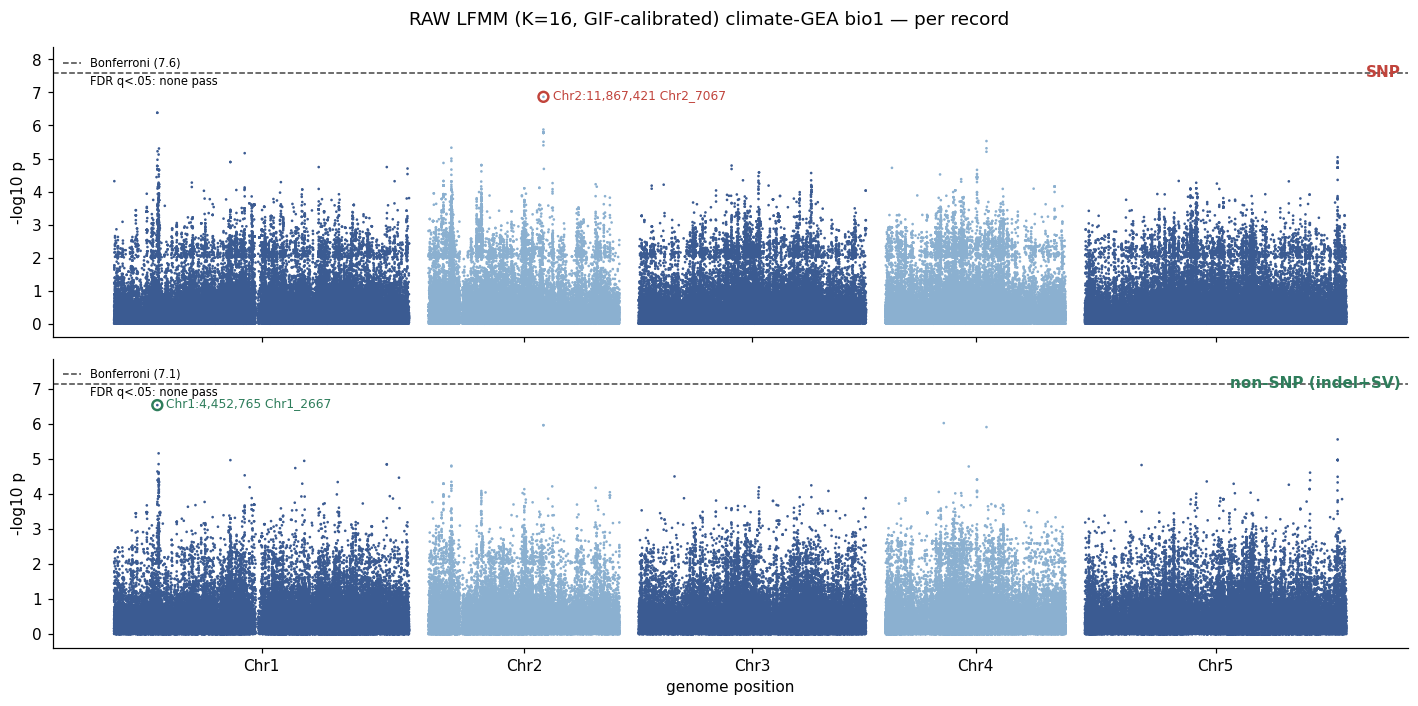

In [3]:
cols={'Chr1':'#3b5b92','Chr2':'#8bb0d0','Chr3':'#3b5b92','Chr4':'#8bb0d0','Chr5':'#3b5b92'}
def _bh(p):
    p=np.asarray(p,float); n=len(p); o=np.argsort(p); q=np.empty(n)
    q[o]=(p[o]*n)/(np.arange(n)+1); q[o]=np.minimum.accumulate(q[o][::-1])[::-1]; return np.clip(q,0,1)
def manhattan(getD, title, fname, ptcol_by_chrom=True, cap=None):
    fig,axes=plt.subplots(2,1,figsize=(13,6.5),sharex=True)
    for ax,cls in zip(axes,['snp','nonsnp']):
        d=getD(cls).copy()
        # per-panel significance lines from THIS panel's p-values
        pv=d.pval.to_numpy(float); pv=pv[np.isfinite(pv)]; nt=len(pv)
        bonf=-np.log10(0.05/nt); pas=pv[_bh(pv)<0.05]
        fdr=float(-np.log10(pas.max())) if pas.size else None
        n_over=0
        if cap is not None:
            n_over=int((d.nlp>cap).sum()); d['nlp']=d.nlp.clip(upper=cap)
        # seam-free thinning: UNIFORM random subsample (constant keep-prob across y,
        # so no density discontinuity) + always keep the real hits (nlp>2)
        base=d.sample(frac=min(1.0,250000/len(d)),random_state=0) if len(d)>250000 else d
        t=pd.concat([base,d[d.nlp>2]]).drop_duplicates(subset=['gx','nlp'])
        c=t.chrom.map(cols) if ptcol_by_chrom else ACC[cls]
        ax.scatter(t.gx,t.nlp,s=3,c=c,rasterized=True,linewidths=0)
        ax.axhline(bonf,ls='--',lw=1.0,color='#444',label=f'Bonferroni ({bonf:.1f})')
        if fdr is not None: ax.axhline(fdr,ls=':',lw=1.3,color='#b8860b',label=f'FDR q<.05 ({fdr:.1f})')
        else: ax.plot([],[],' ',label='FDR q<.05: none pass')
        top=d.nlargest(1,'nlp').iloc[0]
        ax.scatter([top.gx],[top.nlp],s=42,facecolors='none',edgecolors=ACC[cls],linewidths=1.6,zorder=5)
        lab=f"{top.chrom}:{int(top.pos):,} {top.block}"
        if cap is not None and n_over: lab+=f"  (+{n_over} blocks capped at {cap}: Z_pVal underflow)"
        ax.annotate(lab,(top.gx,top.nlp),xytext=(6,-1),textcoords='offset points',fontsize=8,color=ACC[cls])
        ax.set_ylabel('-log10 p' + (f' (capped {cap})' if cap else ''))
        ax.text(0.995,0.90,NAME[cls],transform=ax.transAxes,ha='right',fontweight='bold',color=ACC[cls])
        ytop=max(float(d.nlp.max()),bonf)*1.10
        ax.set_ylim(-0.4, min(ytop,cap+0.6) if cap else ytop)
        ax.legend(loc='upper left',fontsize=7.5,frameon=False,handlelength=1.6)
    axes[1].set_xticks(ticks); axes[1].set_xticklabels(CHR); axes[1].set_xlabel('genome position')
    fig.suptitle(title,y=0.98); fig.tight_layout()
    fig.savefig(f'{OUT}/{fname}',dpi=150,bbox_inches='tight'); print('wrote',fname); plt.show()
manhattan(lambda c: rec[c], 'RAW LFMM (K=16, GIF-calibrated) climate-GEA bio1 — per record',
          'manhattan_raw_snp_vs_nonsnp.png')

## (2) WZA Manhattan — clq0.9 haploblock aggregation
Same two scans, but each point is a **clq0.9 block** WZA `Z_pVal` (deg7-cap2000). This is the block-level test on the finer, more-trusted haploblocks.

WZA Z_pVal underflow (==0) blocks: {'snp': 13, 'nonsnp': 0}


wrote manhattan_wza_clq09_snp_vs_nonsnp.png


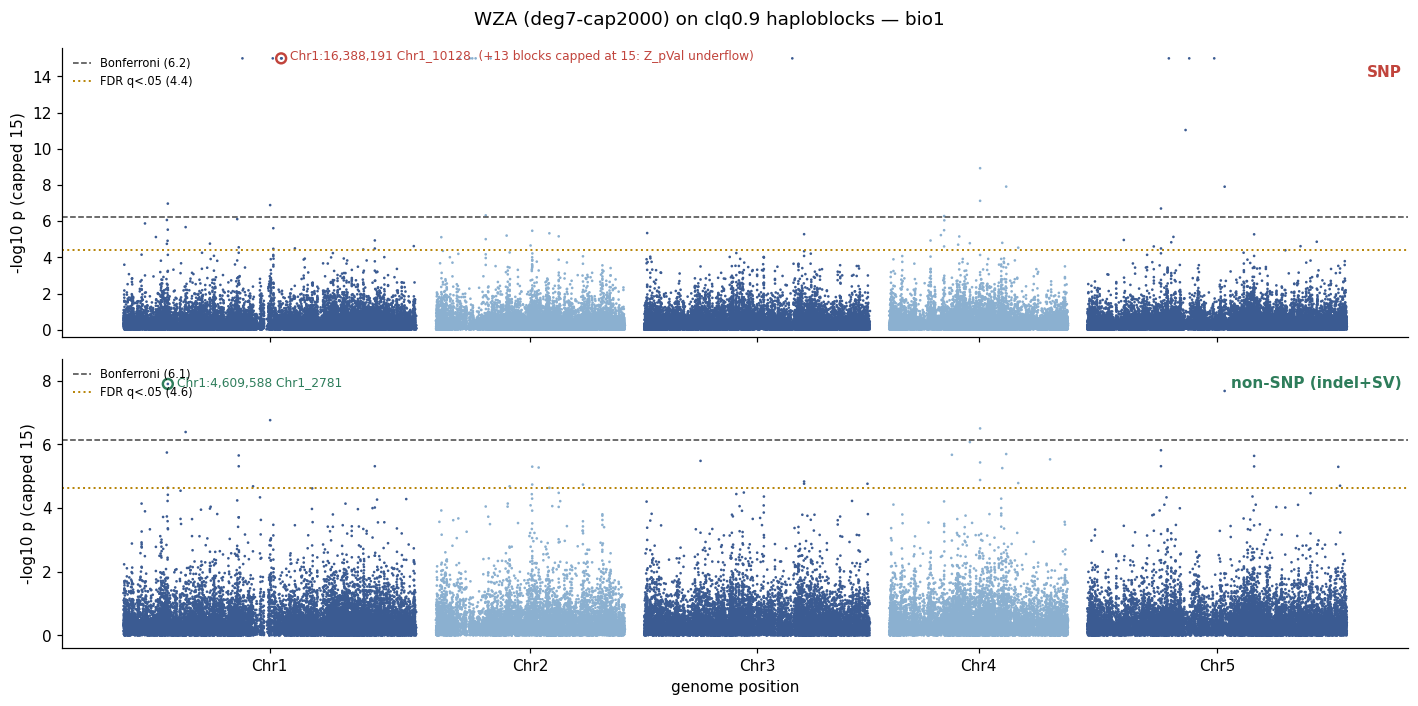

In [4]:
# WZA on the fine clq0.9 SNP blocks produces machine-zero (underflow) Z_pVal for a
# handful of blocks -> cap display at 15 so both panels are readable/comparable.
n_uf={c:int((wza[c].Z_pVal<=0).sum()) for c in ['snp','nonsnp']}
print('WZA Z_pVal underflow (==0) blocks:', n_uf)
manhattan(lambda c: wza[c], 'WZA (deg7-cap2000) on clq0.9 haploblocks — bio1',
          'manhattan_wza_clq09_snp_vs_nonsnp.png', cap=15)

## (2b) Site-level PC1 raw LFMM Manhattan — the honest unit + composite axis
The plot-level bio1 scan above has no genome-wide-significant hits (pseudoreplication: 355 plots, 31 climate values). The **honest unit** is the 31 flower-weighted site means, one observation per climate value. Here the env is **PC1 of the 19 bioclim vars** (the best-calibrated composite axis, GIF≈1). p = deflate-only fair p; MAF = site-level MAF. This is where the non-SNP class produces real Bonferroni hits that SNPs miss.

snp: PC1 site-level, MAF>=0.05 n=1,948,677  min p=1.2e-07  Bonferroni-sig=0
nonsnp: PC1 site-level, MAF>=0.05 n=678,055  min p=1.6e-11  Bonferroni-sig=1


wrote manhattan_sitepc1_snp_vs_nonsnp.png


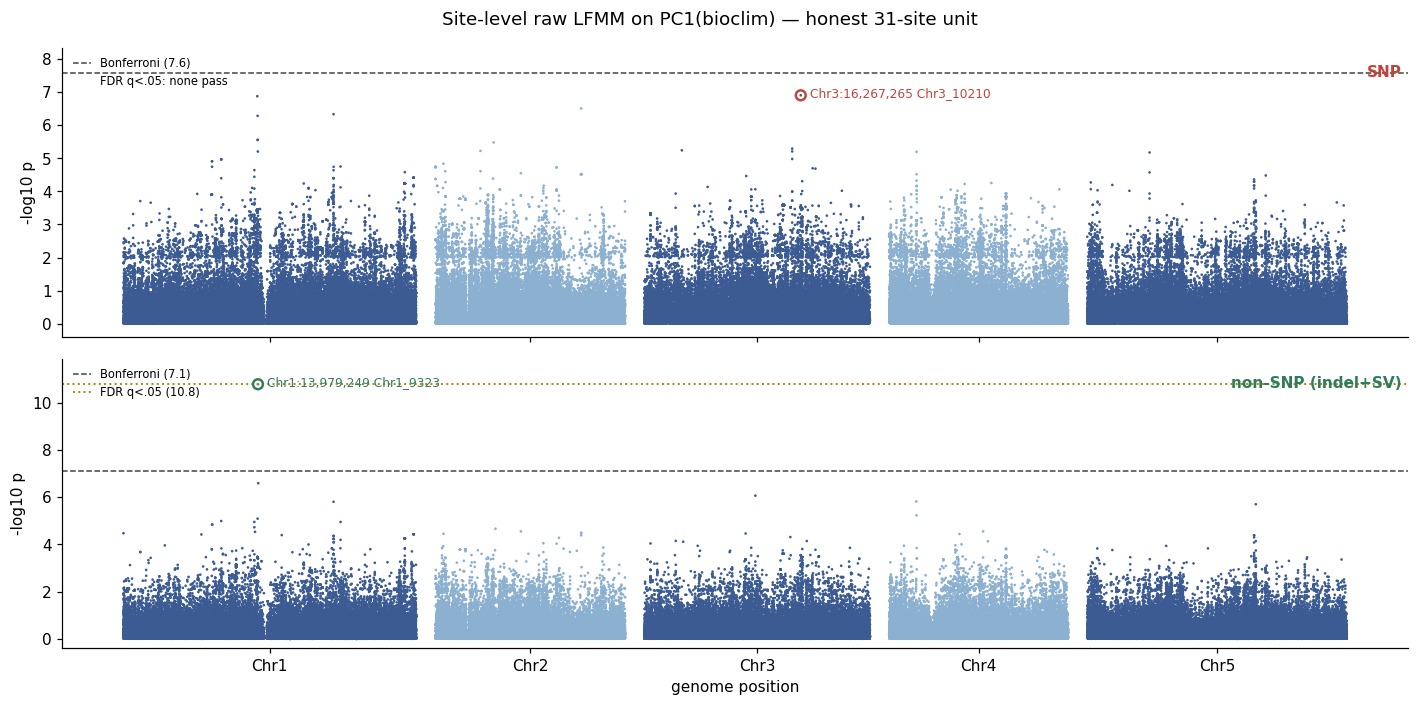

In [5]:
pcr={}
for cls in ['snp','nonsnp']:
    d=pd.read_csv(f'{GNP}/lfmm_{cls}_sitepc1_clq09.csv')
    d=d[np.isfinite(d.pval)].copy(); d['nlp']=-np.log10(d.pval.clip(1e-300))
    d['gx']=d.pos.astype(float)+d.chrom.map(off)
    pcr[cls]=d
# Bonferroni line per class (site-level, on the MAF>=0.05 set)
for cls in ['snp','nonsnp']:
    m=pcr[cls][pcr[cls].MAF>=0.05]; nb=len(m)
    print(f'{cls}: PC1 site-level, MAF>=0.05 n={nb:,}  min p={m.pval.min():.1e}  '
          f'Bonferroni-sig={(m.pval<0.05/nb).sum()}')
manhattan(lambda c: pcr[c][pcr[c].MAF>=0.05], 'Site-level raw LFMM on PC1(bioclim) — honest 31-site unit',
          'manhattan_sitepc1_snp_vs_nonsnp.png')

## (3) Raw per-record LFMM hits (no WZA) — annotated
Top records straight from `lfmm_test`, with the overlapping TAIR10 gene (±2 kb).

In [6]:
genes=lib.load_genes()
def annotate_records(t):
    a=lib.annotate_svs(t.copy(), flank=2000, genes=genes)
    t=t.copy(); t['gene_name']=a.gene_name.values; t['genes']=a.genes_all.values; return t
def raw_top(cls,n=25):
    t=rec[cls].nsmallest(n,'pval')[['chrom','pos','ref_len','alt_len','sv_size','MAF','block','pval']]
    return annotate_records(t).reset_index(drop=True)
raw_snp=raw_top('snp'); raw_non=raw_top('nonsnp')
raw_snp.to_csv(f'{OUT}/raw_top_records_snp_annotated.csv',index=False)
raw_non.to_csv(f'{OUT}/raw_top_records_nonsnp_annotated.csv',index=False)
pd.set_option('display.width',220,'display.max_colwidth',38)
print('records p<1e-5 — SNP %d | non-SNP %d'%((rec['snp'].pval<1e-5).sum(),(rec['nonsnp'].pval<1e-5).sum()))

records p<1e-5 — SNP 29 | non-SNP 7


### Raw top SNP records

In [7]:
raw_snp

,chrom,pos,ref_len,alt_len,sv_size,MAF,block,pval,gene_name,genes
0,Chr2,11867421,1,1,0,0.074642,Chr2_7067,1.357882e-07,AT2G27860,AT2G27860
1,Chr1,4445932,1,1,0,0.095196,Chr1_2667,4.120235e-07,AT1G13030,AT1G13030;AT1G13040
2,Chr1,4451893,1,1,0,0.095196,Chr1_2667,4.120235e-07,AT1G13050,AT1G13050;AT1G13060
3,Chr2,11862477,1,1,0,0.058013,Chr2_7062,1.327031e-06,AT2G27830,AT2G27830;AT2G27840;AT2G27860
4,Chr2,11867429,1,1,0,0.071522,Chr2_7067,1.649211e-06,AT2G27860,AT2G27860
5,Chr2,11867824,1,1,0,0.071522,Chr2_7067,1.649211e-06,AT2G27860,AT2G27860
6,Chr2,11867878,1,1,0,0.071522,Chr2_7067,1.649211e-06,AT2G27860,AT2G27860
7,Chr2,11867936,1,1,0,0.071522,Chr2_7067,1.649211e-06,AT2G27860,AT2G27860
8,Chr2,11868025,1,1,0,0.071522,Chr2_7067,1.649211e-06,AT2G27860,AT2G27860
9,Chr2,11862443,1,1,0,0.061543,Chr2_7062,1.665276e-06,AT2G27830,AT2G27830;AT2G27840;AT2G27860


### Raw top non-SNP records

In [8]:
raw_non

,chrom,pos,ref_len,alt_len,sv_size,MAF,block,pval,gene_name,genes
0,Chr1,4452765,2,1,1,0.090196,Chr1_2667,2.925030e-07,AT1G13050,AT1G13050;AT1G13060
1,Chr4,6017308,21,1,20,0.053384,Chr4_3734,9.524861e-07,AT4G09490,AT4G09490;AT4G09500
2,Chr2,11862385,2,1,1,0.061543,Chr2_7062,1.092440e-06,AT2G27830,AT2G27830;AT2G27840
3,Chr2,11867348,2,2,0,0.071522,Chr2_7067,1.094834e-06,AT2G27860,AT2G27860
4,Chr4,10422792,2,2,0,0.070854,Chr4_8412,1.238099e-06,AT4G19020,AT4G19020;AT4G19030
5,Chr5,26072826,1,33,32,0.088659,Chr5_17877,2.785236e-06,AT5G65240,AT5G65240
6,Chr1,4586276,1,2,1,0.094979,Chr1_2762,6.949782e-06,AT1G13370,AT1G13370
7,Chr5,26071027,1,10,9,0.106598,Chr5_17877,1.077394e-05,AT5G65230,AT5G65230
8,Chr5,26071482,2,1,1,0.106598,Chr5_17877,1.077394e-05,AT5G65230,AT5G65230
9,Chr5,26072261,2,2,0,0.106598,Chr5_17877,1.077394e-05,,


## (4) Class-specific clq0.9 blocks — do the scans hit the same blocks?
Aggregate to clq0.9 blocks and find **SNP-specific** vs **non-SNP-specific** peaks, under BOTH the raw scan (block peak = min per-record p) and the WZA scan (block `Z_pVal`). A block is class-specific if it's a top-50 peak in one scan and rank >500 (or absent) in the other. Concordance = shared-block peak Spearman.

In [9]:
def block_min_raw(cls):
    g=rec[cls].groupby('block').agg(p=('pval','min'),n=('pval','size'),chrom=('chrom','first')).reset_index()
    g['rank']=g.p.rank(method='min'); return g
def block_wza(cls):
    g=wza[cls][['block','Z_pVal','chrom','pos','SNPs']].rename(columns={'Z_pVal':'p','SNPs':'n'}).copy()
    g['rank']=g.p.rank(method='min'); return g
def specific(scoref, label):
    bs=scoref('snp').rename(columns={'p':'p_snp','n':'n_snp','rank':'r_snp'})
    bn=scoref('nonsnp').rename(columns={'p':'p_non','n':'n_non','rank':'r_non'})
    m=bs[['block','p_snp','n_snp','r_snp','chrom']].merge(
        bn[['block','p_non','n_non','r_non']],on='block',how='outer')
    sh=m.dropna(subset=['p_snp','p_non'])
    rho=st.spearmanr(-np.log10(sh.p_snp.clip(1e-300)),-np.log10(sh.p_non.clip(1e-300))).correlation
    B=10**9; m['r_snp']=m.r_snp.fillna(B); m['r_non']=m.r_non.fillna(B)
    snp_spec=m[(m.r_snp<=50)&(m.r_non>500)].sort_values('p_snp')
    non_spec=m[(m.r_non<=50)&(m.r_snp>500)].sort_values('p_non')
    print(f'[{label}] clq0.9 blocks snp={bs.block.nunique():,} non={bn.block.nunique():,} '
          f'shared={len(sh):,} | peak Spearman rho={rho:.3f} | '
          f'SNP-specific={len(snp_spec)} nonSNP-specific={len(non_spec)}')
    return m, snp_spec, non_spec
def annotate_blocks(spec, cls_lead):
    rows=[]
    for _,r in spec.iterrows():
        sub=rec[cls_lead][rec[cls_lead].block==r.block]
        if not len(sub):
            continue
        lead=sub.nsmallest(1,'pval').iloc[0]
        rows.append(dict(block=r.block, chrom=lead.chrom, lead_pos=int(lead.pos),
            sv_size=int(abs(lead.alt_len-lead.ref_len)), MAF=round(float(lead.MAF),3),
            ref_len=int(lead.ref_len), p_snp=r.get('p_snp'), p_non=r.get('p_non')))
    t=pd.DataFrame(rows)
    if len(t):
        a=lib.annotate_svs(t.rename(columns={'lead_pos':'pos'}),flank=2000,genes=genes)
        t['gene_name']=a.gene_name.values; t['genes']=a.genes_all.values
    return t
mr,snp_spec_raw,non_spec_raw = specific(block_min_raw,'RAW')
mw,snp_spec_wza,non_spec_wza = specific(block_wza,'WZA')
# annotate the WZA-based class-specific blocks (block-level test) + save
non_wza_ann=annotate_blocks(non_spec_wza,'nonsnp'); snp_wza_ann=annotate_blocks(snp_spec_wza,'snp')
non_wza_ann.to_csv(f'{OUT}/wza_nonsnp_specific_blocks_annotated.csv',index=False)
snp_wza_ann.to_csv(f'{OUT}/wza_snp_specific_blocks_annotated.csv',index=False)
# also the raw-based ones
annotate_blocks(non_spec_raw,'nonsnp').to_csv(f'{OUT}/raw_nonsnp_specific_blocks_annotated.csv',index=False)
annotate_blocks(snp_spec_raw,'snp').to_csv(f'{OUT}/raw_snp_specific_blocks_annotated.csv',index=False)

[RAW] clq0.9 blocks snp=81,704 non=68,657 shared=68,415 | peak Spearman rho=0.553 | SNP-specific=28 nonSNP-specific=21
[WZA] clq0.9 blocks snp=81,704 non=68,657 shared=68,415 | peak Spearman rho=0.662 | SNP-specific=24 nonSNP-specific=11


### non-SNP-specific clq0.9 blocks (WZA) — peaks SNPs miss

In [10]:
non_wza_ann.head(20)

,block,chrom,lead_pos,sv_size,MAF,ref_len,p_snp,p_non,gene_name,genes
0,Chr4_4205,Chr4,6514231,0,0.062,2,0.006433,0.000002,AT4G10540,AT4G10540
1,Chr4_12283,Chr4,16717614,3,0.123,2,0.765414,0.000003,AT4G35120,AT4G35120
2,Chr1_8327,Chr1,11979068,0,0.363,4,0.003224,0.000005,AT1G33060,AT1G33060
3,Chr2_6226,Chr2,10723971,1,0.062,1,0.033795,0.000005,AT2G25170,AT2G25170;AT2G25180
4,Chr3_10635,Chr3,16612109,0,0.103,3,0.170894,0.000015,AT3G45280,AT3G45280
5,Chr3_15391,Chr3,23198308,1,0.161,1,0.589472,0.000017,AT3G62710,AT3G62710
6,Chr1_9232,Chr1,13467654,0,0.141,2,0.020292,0.000021,AT1G36070,AT1G36070
7,Chr1_12415,Chr1,19610530,18,0.212,1,0.053308,0.000024,AT1G52630,AT1G52630;AT1G52640;AT1G52650
8,Chr5_10611,Chr5,17169913,0,0.109,2,0.001917,0.000043,AT5G42810,AT5G42810;AT5G42820
9,Chr5_4949,Chr5,8231543,0,0.303,2,0.003937,0.000046,AT5G24230,AT5G24230;AT5G24240


### SNP-specific clq0.9 blocks (WZA) — peaks the non-SNP scan misses

In [11]:
snp_wza_ann.head(20)

,block,chrom,lead_pos,sv_size,MAF,ref_len,p_snp,p_non,gene_name,genes
0,Chr1_10128,Chr1,16412833,0,0.092,1,0.000000e+00,0.589309,AT1G43580,AT1G43580
1,Chr5_5176,Chr5,8500791,0,0.101,1,0.000000e+00,0.633222,AT5G24770,AT5G24770
2,Chr3_9512,Chr3,15391118,0,0.096,1,0.000000e+00,0.521638,AT3G43470,AT3G43470
3,Chr5_6445,Chr5,10617311,0,0.292,1,0.000000e+00,0.426850,,
4,Chr2_2923,Chr2,5712435,0,0.089,1,0.000000e+00,0.620979,,
5,Chr2_2345,Chr2,4177925,0,0.324,1,0.000000e+00,0.510508,,
6,Chr2_2209,Chr2,3840904,0,0.081,1,0.000000e+00,0.698755,,
7,Chr5_7585,Chr5,13169407,0,0.107,1,0.000000e+00,0.274474,,
8,Chr2_1848,Chr2,2493105,0,0.052,1,0.000000e+00,0.248753,,
9,Chr1_9715,Chr1,15478680,0,0.159,1,0.000000e+00,0.243891,,


### Read-out
- Two Manhattans (raw per-record + WZA on clq0.9) let you compare the scans at both resolutions; the finer clq0.9 blocks localize signal better than the phase-1 LD blocks.
- The shared-block peak Spearman (printed above) quantifies overall SNP↔non-SNP concordance; the annotated tables name the genes under each class-specific block.
- Non-SNP-specific, SV-led blocks are the candidates for 'signal SNPs miss'.